In [921]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [922]:
df = pd.read_csv("C:/Users/u461262/OneDrive - WNS/Desktop/Python/Project/salary_prediction_data.csv")
df.head()

,years_experience,education_level,performance_score,salary
0,5.993428,3,3.140886,77911.99
1,4.723471,1,1.231561,49464.75
2,6.295377,3,3.323168,79956.37
3,8.046060,1,2.852397,65954.34
4,4.531693,3,2.533963,66644.10


In [923]:
df.dtypes

years_experience     float64
education_level        int64
performance_score    float64
salary               float64
dtype: object

In [924]:
df.shape

(1000, 4)

In [925]:
df.describe()

,years_experience,education_level,performance_score,salary
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.041082,1.976000,3.011730,67010.468210
std,1.951552,0.808751,0.932806,9632.517347
min,0.000000,1.000000,1.000000,33235.430000
25%,3.704819,1.000000,2.357997,60533.340000
50%,5.050601,2.000000,3.000867,67244.220000
75%,6.295888,3.000000,3.671648,73226.682500
max,12.705463,3.000000,5.000000,101228.720000


In [926]:
df.isnull().sum()

years_experience     0
education_level      0
performance_score    0
salary               0
dtype: int64

In [927]:
df[df.duplicated()]

,years_experience,education_level,performance_score,salary


In [928]:
null = df[df.isnull().any(axis=1)]
print(null)

Empty DataFrame
Columns: [years_experience, education_level, performance_score, salary]
Index: []


C:\Users\u461262\AppData\Local\Temp\ipykernel_6404\2174957335.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['salary']);


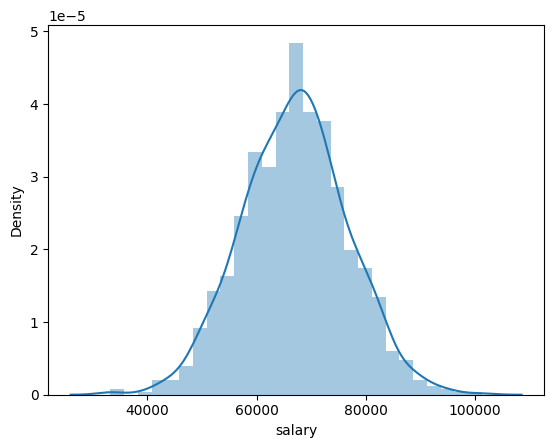

In [929]:
sns.distplot(df['salary']);
plt.show()

In [930]:
print('skewness', df['salary'].skew())
print('kurtosis', df['salary'].kurt())

skewness 0.0019870578903112266
kurtosis 0.15837075703522885


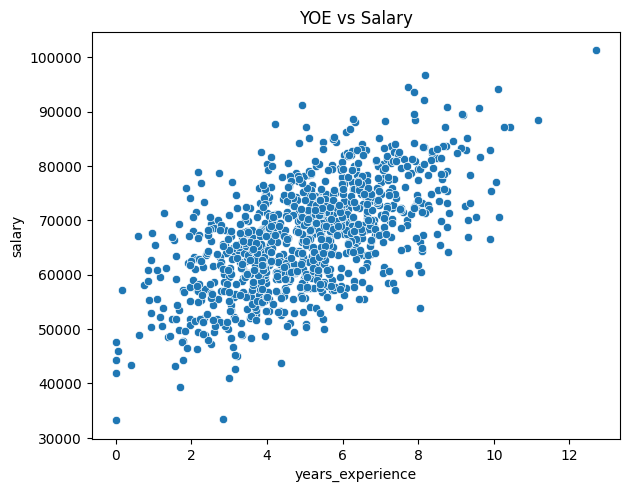

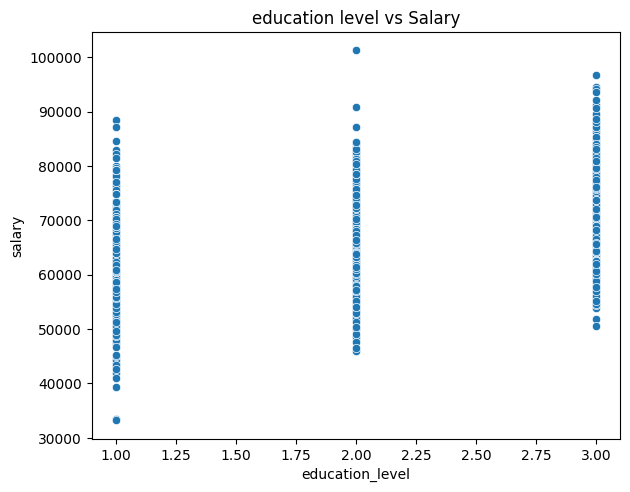

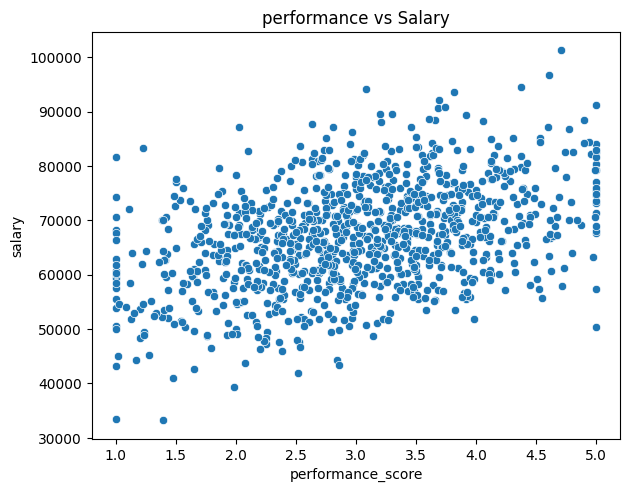

In [931]:
sns.scatterplot(x='years_experience', y ='salary', data = df)
plt.tight_layout()
plt.title('YOE vs Salary')
plt.show()
sns.scatterplot(x='education_level', y ='salary', data = df)
plt.tight_layout()
plt.title('education level vs Salary')
plt.show()
sns.scatterplot(x='performance_score', y ='salary', data = df)
plt.tight_layout()
plt.title('performance vs Salary')
plt.show()

From above scatterplot we can conclude the more year of experience the more is salary as it's going upward only

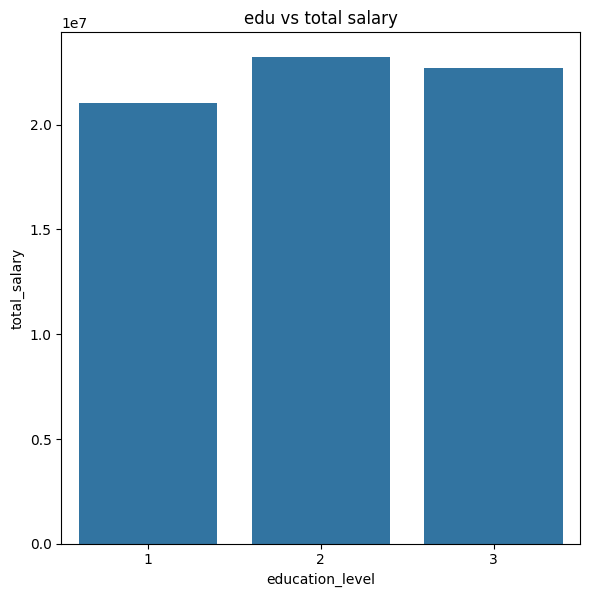

In [932]:
total_salary_edu = df.groupby(df['education_level'])['salary'].sum().reset_index()
total_salary_edu.columns = ['education_level', 'total_salary']
plt.figure(figsize= (6,6))
sns.barplot(x = total_salary_edu['education_level'], y = total_salary_edu['total_salary'], data = total_salary_edu)
plt.tight_layout()
plt.title('edu vs total salary')
plt.show()



In [933]:
year = df['years_experience'].values
q1 = np.percentile(df['years_experience'], 25)
q3 = np.percentile(df['years_experience'], 75)

IQR = q3-q1
lowerbound = q1-1.5*IQR
upperbound = q3+1.5*IQR
outlier = df[(df['years_experience']<lowerbound) | (df['years_experience']>upperbound)]
print(outlier)

     years_experience  education_level  performance_score     salary
179         10.440338                2           2.025471   87239.96
209         12.705463                2           4.710613  101228.72
478         11.157762                1           3.659246   88523.72
755         10.264764                1           3.462061   87159.64


In [934]:
print(df['years_experience'].skew())
print(df['years_experience'].kurt())

0.1448998239505024
-0.0018699054915765068


<Axes: xlabel='years_experience'>

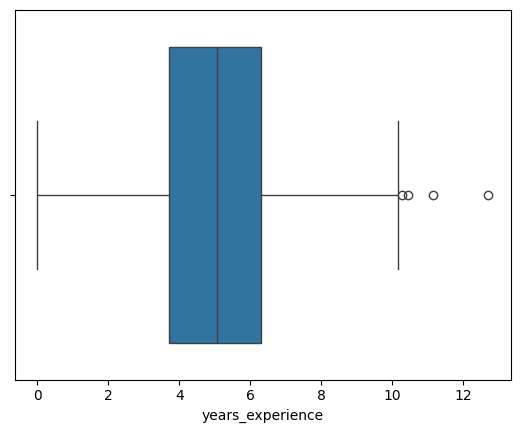

In [935]:
sns.boxplot(x=df['years_experience'])

In [936]:
#df = df.drop(outlier.index)

In [937]:
print(df['years_experience'].skew())
print(df['years_experience'].kurt())

0.1448998239505024
-0.0018699054915765068


<Axes: xlabel='years_experience'>

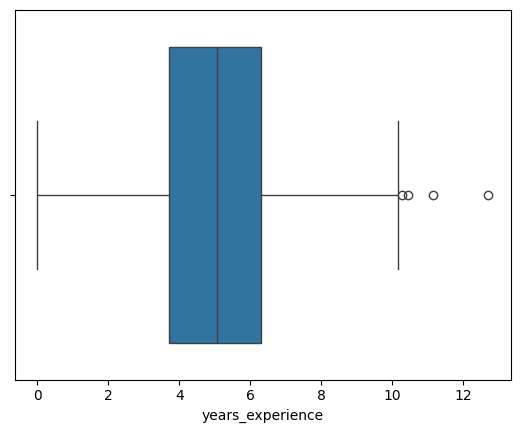

In [938]:
sns.boxplot(x=df['years_experience'])

In [939]:
sal = df['salary'].values
q1 = np.percentile(df['salary'], 25)
q3 = np.percentile(df['salary'], 75)

IQR = q3-q1
lowerbound = q1-1.5*IQR
upperbound = q3+1.5*IQR
outlier = df[(df['salary']<lowerbound) | (df['salary']>upperbound)]
print(outlier)

     years_experience  education_level  performance_score     salary
209         12.705463                2           4.710613  101228.72
282          8.172034                3           4.612221   96659.24
425          7.737263                3           4.374438   94446.36
487          2.836904                1           1.000000   33349.93
635          1.690287                1           1.984906   39251.34
646          0.000000                1           1.392339   33235.43
762         10.120169                3           3.085318   94086.61
832          2.991718                1           1.477641   40916.26
965          7.880234                3           3.813205   93569.29


In [940]:
print(df['salary'].skew())
print(df['salary'].kurt())

0.0019870578903112266
0.15837075703522885


<Axes: xlabel='salary'>

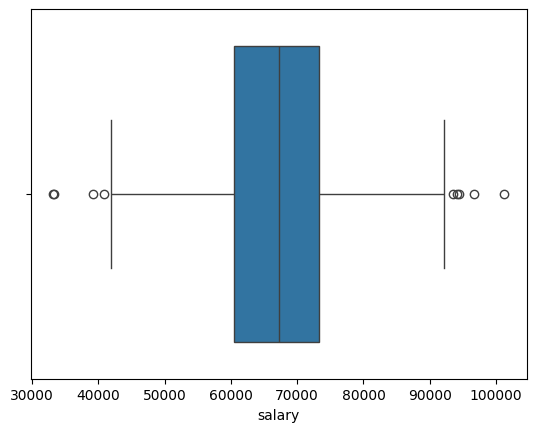

In [941]:
sns.boxplot(x= df['salary'])

In [942]:
#df = df.drop(outlier.index)

In [943]:
print(df['salary'].skew())
print(df['salary'].kurt())

0.0019870578903112266
0.15837075703522885


<Axes: xlabel='salary'>

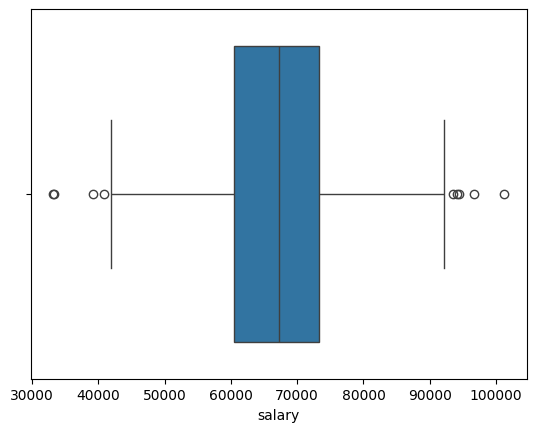

In [944]:
sns.boxplot(x= df['salary'])

In [945]:
df['salary'] = np.log1p(df['salary'])
df['years_experience'] = np.log1p(df['years_experience'])

In [946]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x = add_constant(df.drop('salary', axis = 1))
vif = pd.DataFrame()
vif['features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
print(vif)

            features        VIF
0              const  39.077836
1   years_experience   1.000850
2    education_level   1.000471
3  performance_score   1.000794


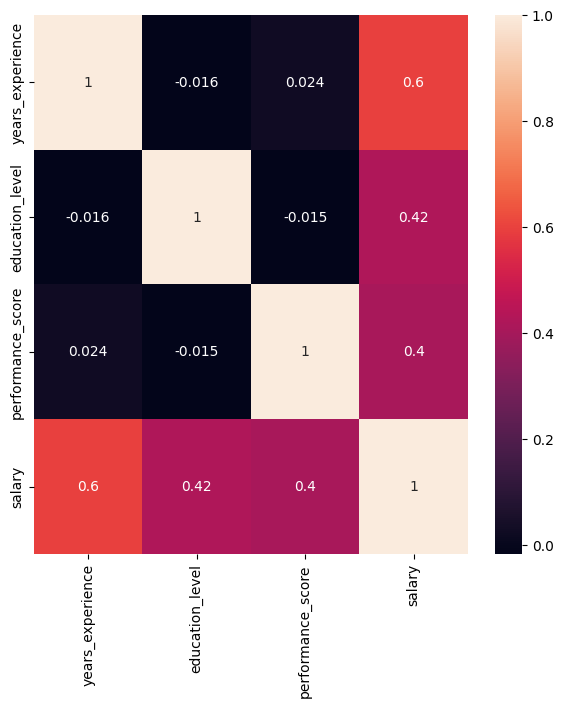

In [947]:
plt.figure(figsize = (7,7))
cor = df.corr()
sns.heatmap(cor, annot = True)
plt.show()

In [948]:
from sklearn.preprocessing import StandardScaler
df.drop('salary', axis = 1)
sclaer = StandardScaler()
x_sclaed = sclaer.fit_transform(x)

In [949]:
from sklearn.model_selection import train_test_split
x = df.drop('salary', axis = 1)
y = df['salary']
x_train, x_test,y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)


In [950]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(x_test.shape)

(800, 3)
(200, 3)
(800,)
(200, 3)


In [951]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
r = Ridge(alpha = 1.0)
l = Lasso(alpha = 0.1)
models = {'Linear Regression' : lr, 'Ridge' : r, 'Lasso':r}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred_log = model.predict(x_test)
    y_pred_actual = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2 = r2_score(y_test_actual, y_pred_actual)
    print('rmse', rmse)
    print('r2 score', r2)

rmse 5206.813854708706
r2 score 0.700716467940472
rmse 5205.5344006752575
r2 score 0.7008635338760385
rmse 5205.5344006752575
r2 score 0.7008635338760385


In [955]:
new_profile = pd.DataFrame({
    'years_experience': [5],
    'education_level': [3],
    'performance_score': [4]
})
new_profile['years_experience'] = np.log1p(new_profile['years_experience'])
predicted = r.predict(new_profile)
predicted_salary = np.expm1(predicted)
print(predicted_salary)

[77630.49462644]
